<a href="https://colab.research.google.com/github/ivachuk1993/customer-retention-cohort-analysis/blob/main/analise_cohort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/analise_cohort/data/online_retail_II.csv'

df = pd.read_csv(file_path)

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


- head () é a unção que exibiu as 5 primeira linhas o DataFrame, já a unção tail() nos motra as 5 últimas linhas;

Descrição das colunas:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


- A função info() nos mostra logo após o RangeIndex o número de entradas 1067371, bem como, o total e colunas que são 8;
- Podemos observar que as colunas Description e CostumerID possuem valores abaixo do número total de entradas, sugerindo valores missing;
- Como o foco da análise é uma análise de cohort, não focaremos na coluna Description, apenas na coluna CustomerID, que é a nossa chave de identificação de clientes;
- Podemos excluir as linhas que não possuem a variável CustomerID, pois se não coneguimos uma identificação o cliente, logo, não poderemos acompanhar o seu comportamento.


- Antes da exclusão de valores missing;

In [5]:
df.shape

(1067371, 8)

In [6]:
df.dropna(subset=['Customer ID'], inplace=True)

- Com o uso do inplace=True nós alteramos o DataFrame original, removendo as linhas missing apenas da coluna Customer ID;
- A seguir temos como ficou nosso DataFrame após a exclusão dos valores missing;

In [7]:
df.shape

(824364, 8)

- Foi perdida uma quantidade significativa de linhas;
- Na sequência geraremos uma estatítica descritiva das colunas.

In [8]:
df.describe()

,Quantity,Price,Customer ID
count,824364.000000,824364.000000,824364.000000
mean,12.414574,3.676800,15324.638504
std,188.976099,70.241388,1697.464450
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13975.000000
50%,5.000000,1.950000,15255.000000
75%,12.000000,3.750000,16797.000000
max,80995.000000,38970.000000,18287.000000


- A quantidade média de itens por compra é próxima de 12, já a mediana é 5. Pensando nesses valores, podemos inferir que nosso distribuição é assimétrica;
- Agora verificaremos quantos 'invoice' cada cliente possui;
- Resumidamente queremos entender quantidade de notas fiscais de cada cliente, quantidade real de compras realizadas e usaremos a função nunique() para isso, não usaremos, por exemplo, a função size(), justamente porque ela somará a quantidade de linhas existentes, lembrando que um mesmo cliente pode ter vários invoices, pois cada compra pode ter mais do que um item, gerando um mesmo número de invoices se repetindo várias vezes.
- Em, outras palavras, cada 'invoice' é referente a um item da compra, ou seja uma compra de 10 itens, terá 10 'invoices' iguais, para considerarmos apenas uma compra com os 10 itens, usaremos a função nunique(), para a contagem única do 'invoice';

- Agora queremos entender a distruição de compras feitas e quantas compras cada cliente de fato efetivou;
- Quantos 'invoices' cada cliente possui?

In [9]:
df.groupby('Customer ID')['Invoice'].nunique().sort_values()

,Invoice
Customer ID,
12366.0,1
15776.0,1
15772.0,1
12387.0,1
12382.0,1
...,...
14606.0,259
15311.0,270
17841.0,289


- Com o método .sort_values(), ordenamos os clientes por número de compras de forma única.

In [10]:
orders_per_customer=df.groupby('Customer ID')['Invoice'].nunique()

In [11]:
orders_per_customer.describe()

,Invoice
count,5942.000000
mean,7.552339
std,15.972262
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,510.000000


- Com a função .describe() podemos inferir que a distribuição é realmente assimétrica, muitos clientes com poucas compras e também poucos clientes com muitas comopras;
- Para facilitar nossa visualização podemos gerar um histograma.

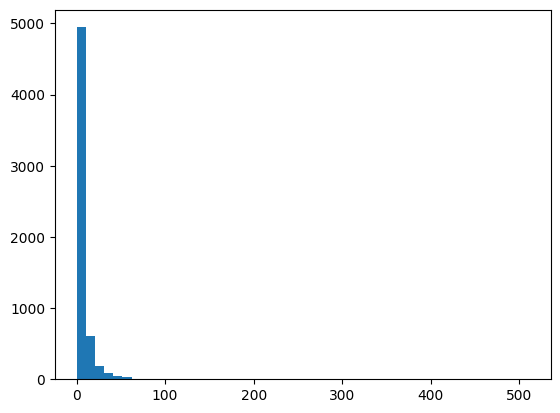

In [22]:
import matplotlib.pyplot as plt
_ = plt.hist(orders_per_customer, bins=50)

- A maioria se concentra em 4 compras;
- Podemos inferir que teremos baixa retenção dos clientes, sendo assim, vamos verificar os clientes que seguem fazendo compras mensalmente;
- Sendo assim, o agrupamento utilizado será pela chave de identificação do cliente,data da compra e a chave de identificação da compra;
- realizarei uma breve limpeza de valores duplicados;

In [13]:
df = df[['Customer ID', 'Invoice', 'InvoiceDate']].drop_duplicates()

- A partir daqui iniciaremos nossas cohorts;
- Executaremos cohorts mensais justamente para identificar os meses que os clientes fizeram compras;
- Sendo assim, criaremos uma coluna para o mês de compras.

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [15]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

- Criamos a coluna Invoicemonth e além disso criamos um campo para o mês da compra;
- Agora precisaremos das datas, a cohort de cada cliente se inicia no mês da primeira compra que ele executou;
- No código abaixo estaremos criando a coluna Cohort, e pegando a primeira data de comra para cada cliente e convertendo a data para mês e ano.

In [16]:
df['Cohort'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

- Usou-se o trasnform() para criar a menor data de compra sem perder nossa estrutura inicial dos dados.

In [23]:
df.head()

,Customer ID,Invoice,InvoiceDate,InvoiceMonth,Cohort
0,13085.0,489434,2009-12-01 07:45:00,2009-12,2009-12
8,13085.0,489435,2009-12-01 07:46:00,2009-12,2009-12
12,13078.0,489436,2009-12-01 09:06:00,2009-12,2009-12
31,15362.0,489437,2009-12-01 09:08:00,2009-12,2009-12
54,18102.0,489438,2009-12-01 09:24:00,2009-12,2009-12


- Podemos notar que o consumidor de ID 13085.0 realizou duas compras em 2009-12, essas duas compras não nos interessam, a questão aqui é entender que ele estava fazendo compra nesse mês e em quais outros meses ele também fez;
- Faremos assim a contagem de consumidores no início de cada cohort e quantos deles aparecem também nos meses seguintes, com isso, agruparemos por mês de Invoce e Cohort.

In [24]:
df_cohort = df.groupby(['Cohort', 'InvoiceMonth']).agg(n_customers=('Customer ID', 'nunique')).reset_index(drop=False)
df_cohort.head()

,Cohort,InvoiceMonth,n_customers
0,2009-12,2009-12,1045
1,2009-12,2010-01,392
2,2009-12,2010-02,358
3,2009-12,2010-03,447
4,2009-12,2010-04,410


- Boa parte da análise já está resolvida, para facilitar a construção da nossa matriz criaremos uma coluna com a numeração de cada período depois do início da cohort. Para facilitar o entendimento: se o início da cohort foi em dezembro de 2015, o mês de janeiro de 2016 será o número 1, o mês de fevereiro o 2 e assim sucessivamente.

In [26]:
df_cohort['Period'] = (df_cohort.InvoiceMonth - df_cohort.Cohort).apply(lambda i: abs(i.n))
df_cohort

,Cohort,InvoiceMonth,n_customers,Period
0,2009-12,2009-12,1045,0
1,2009-12,2010-01,392,1
2,2009-12,2010-02,358,2
3,2009-12,2010-03,447,3
4,2009-12,2010-04,410,4
...,...,...,...,...
320,2011-10,2011-11,74,1
321,2011-10,2011-12,39,2
322,2011-11,2011-11,192,0
323,2011-11,2011-12,33,1


- Agora criaremos uma pivot_table


In [29]:
cohort_pivot = df_cohort.pivot_table(index='Cohort', columns='Period', values='n_customers')
cohort_pivot

Period,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort,,,,,,,,,,,,,,,,,,,,,
2009-12,1045.0,392.0,358.0,447.0,410.0,408.0,408.0,374.0,355.0,392.0,...,319.0,273.0,316.0,303.0,287.0,274.0,332.0,319.0,427.0,218.0
2010-01,394.0,86.0,119.0,120.0,110.0,115.0,105.0,91.0,114.0,134.0,...,60.0,86.0,74.0,69.0,73.0,93.0,73.0,88.0,29.0,NaN
2010-02,363.0,109.0,82.0,110.0,93.0,76.0,79.0,103.0,100.0,106.0,...,74.0,67.0,61.0,53.0,85.0,90.0,62.0,23.0,NaN,NaN
2010-03,436.0,95.0,113.0,103.0,100.0,87.0,105.0,130.0,126.0,50.0,...,74.0,76.0,69.0,74.0,89.0,93.0,33.0,NaN,NaN,NaN
2010-04,291.0,67.0,58.0,47.0,54.0,67.0,79.0,76.0,33.0,34.0,...,43.0,41.0,41.0,50.0,61.0,19.0,NaN,NaN,NaN,NaN
2010-05,254.0,49.0,45.0,49.0,48.0,66.0,56.0,33.0,17.0,22.0,...,33.0,36.0,42.0,40.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,269.0,58.0,53.0,55.0,62.0,76.0,35.0,25.0,22.0,32.0,...,33.0,37.0,55.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,183.0,38.0,37.0,52.0,55.0,28.0,21.0,28.0,26.0,22.0,...,32.0,45.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,158.0,39.0,50.0,51.0,29.0,21.0,16.0,22.0,23.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Agora editaremos os valores para percentual e criaremos um mapa de calor;
- Além disso, pegaremos os valores inciais da primeira coluna e os aplicaremos em uma divisão como denominador da respectiva coluna, para isso usaremos o iloc;

In [30]:
cohort_size = cohort_pivot.iloc[:,0]
cohort_size

,0
Cohort,
2009-12,1045.0
2010-01,394.0
2010-02,363.0
2010-03,436.0
2010-04,291.0
2010-05,254.0
2010-06,269.0
2010-07,183.0
2010-08,158.0


- Agora realizaremos a divisão dos valores das demais colunas pelo valor da primeira coluna de cada linha. Para isso, utilizaremos o método divide() da biblioteca Pandas. Como desejamos que a divisão ocorra considerando os valores correspondentes em cada linha, utilizamos o parâmetro axis=0, que indica que a operação será alinhada pelos índices das linhas do DataFrame.

In [31]:
retention_matrix = cohort_pivot.divide(cohort_size, axis = 0)
retention_matrix

Period,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.375120,0.342584,0.427751,0.392344,0.390431,0.390431,0.357895,0.339713,0.375120,...,0.305263,0.261244,0.302392,0.289952,0.274641,0.262201,0.317703,0.305263,0.408612,0.208612
2010-01,1.0,0.218274,0.302030,0.304569,0.279188,0.291878,0.266497,0.230964,0.289340,0.340102,...,0.152284,0.218274,0.187817,0.175127,0.185279,0.236041,0.185279,0.223350,0.073604,NaN
2010-02,1.0,0.300275,0.225895,0.303030,0.256198,0.209366,0.217631,0.283747,0.275482,0.292011,...,0.203857,0.184573,0.168044,0.146006,0.234160,0.247934,0.170799,0.063361,NaN,NaN
2010-03,1.0,0.217890,0.259174,0.236239,0.229358,0.199541,0.240826,0.298165,0.288991,0.114679,...,0.169725,0.174312,0.158257,0.169725,0.204128,0.213303,0.075688,NaN,NaN,NaN
2010-04,1.0,0.230241,0.199313,0.161512,0.185567,0.230241,0.271478,0.261168,0.113402,0.116838,...,0.147766,0.140893,0.140893,0.171821,0.209622,0.065292,NaN,NaN,NaN,NaN
2010-05,1.0,0.192913,0.177165,0.192913,0.188976,0.259843,0.220472,0.129921,0.066929,0.086614,...,0.129921,0.141732,0.165354,0.157480,0.047244,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.215613,0.197026,0.204461,0.230483,0.282528,0.130112,0.092937,0.081784,0.118959,...,0.122677,0.137546,0.204461,0.059480,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.207650,0.202186,0.284153,0.300546,0.153005,0.114754,0.153005,0.142077,0.120219,...,0.174863,0.245902,0.092896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.246835,0.316456,0.322785,0.183544,0.132911,0.101266,0.139241,0.145570,0.132911,...,0.202532,0.069620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Agora faremos o mapa de calor.

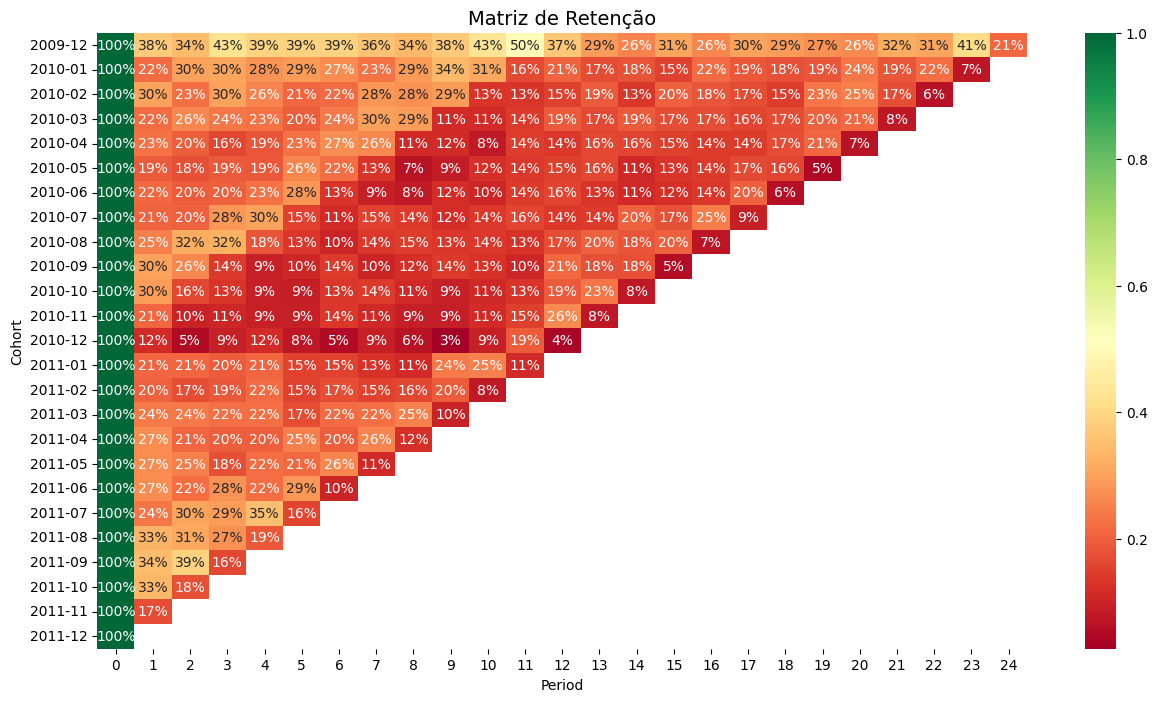

In [33]:
import seaborn as sns

_ = plt.subplots(figsize=(15, 8))
_ = sns.heatmap(
    data = retention_matrix,
    mask = retention_matrix.isnull(),
    annot = True,
    fmt = '.0%',
    cmap = 'RdYlGn'
)

_ = plt.title('Matriz de Retenção', size=14)

Exemplificando: _ = plt.subplots(figsize=(15, 8)); gera uma figura com uma única plotagem (subplot) com tamanho de 15 por 8. O resultado é atribuído a uma variável não usada '_', indicando que não estamos interessados no retorno específico dessa função;
_ = sns.heatmap(...): cria um heatmap a partir do Seaborn, e seus parâmetros são
data = retention_matrix: que são os dados a serem plotados, neste caso, a matriz de retenção retention_matrix;
mask = retention_matrix.isnull(): mascara os valores nulos na matriz, sendo assim, oculta as células que possuem valores nulos;
annot = True: adiciona valores nas células do heatmap;
fmt = '.0%': formata as anotações como porcentagem sem casas decimais;
cmap = 'RdYlGn': determina a paleta de cores do heatmap, a paleta "RdYlGn", abreviação de RedYellowGreen (vermelho, amarelo, verde).
_ = plt.title('Matriz de Retenção', size=14): define o título do gráfico como "Matriz de Retenção" com tamanho de fonte de 14.